Mendownload daftar nama objek (coco.names)...
=== HASIL DETEKSI ===
Terdeteksi 4 truck
Terdeteksi 4 dog
Terdeteksi 9 bicycle


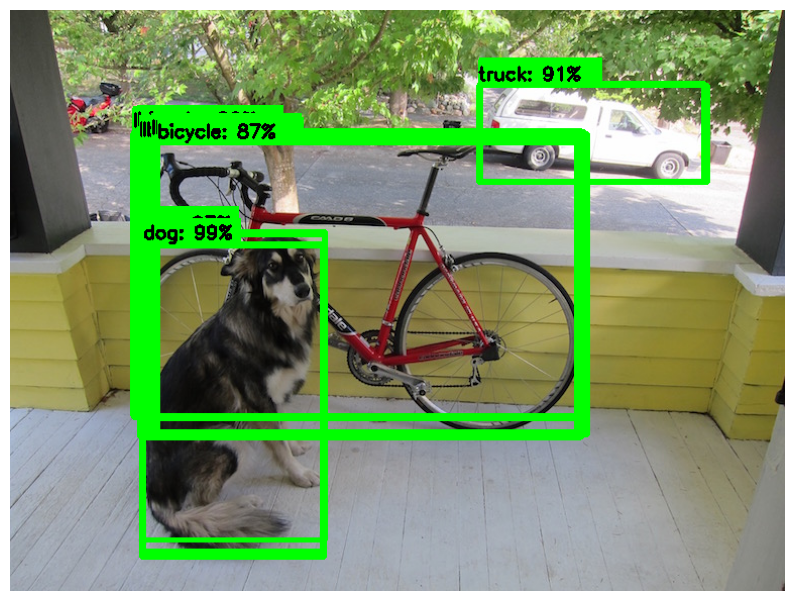

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os
from collections import Counter

# 1. Download file nama-nama kelas (coco.names) jika belum ada
if not os.path.exists("coco.names"):
    print("Mendownload daftar nama objek (coco.names)...")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/coco.names", "coco.names")

# Membaca daftar nama objek
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

# 2. Load Model YOLOv4
net = cv2.dnn.readNetFromDarknet("yolov4.cfg", "yolov4.weights")
try:
    output_layers = net.getUnconnectedOutLayersNames()
except:
    layer_names = net.getLayerNames()
    output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# 3. Load Gambar object.jpg
image = cv2.imread("object.jpg")
height, width, channels = image.shape

# 4. Ubah gambar ke format Blob
blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), swapRB=True, crop=False)
net.setInput(blob)

# 5. Forward Pass (Jalankan prediksi deteksi objek)
outputs = net.forward(output_layers)

# 6. Analisis Hasil Prediksi dan Gambar Kotak
detected_objects = [] # List untuk menyimpan nama benda yang terdeteksi

for output in outputs:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        
        if confidence > 0.5: # Jika model yakin di atas 50%
            # Dapatkan nama benda
            object_name = classes[class_id]
            detected_objects.append(object_name)
            
            # Ambil koordinat Bounding Box
            center_x, center_y, w, h = (detection[0:4] * np.array([width, height, width, height])).astype("int")
            
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)
            
            # Gambar kotak berwarna hijau
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 3)
            
            # Tambahkan Teks (Label dan Persentase Kepercayaan)
            label = f"{object_name}: {int(confidence * 100)}%"
            # Buat background hitam kecil untuk teks agar mudah dibaca
            cv2.rectangle(image, (x, y - 25), (x + len(label)*12, y), (0, 255, 0), -1)
            cv2.putText(image, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

# 7. Menghitung Ringkasan Objek
print("=== HASIL DETEKSI ===")
object_counts = Counter(detected_objects)
if len(object_counts) == 0:
    print("Tidak ada objek yang terdeteksi secara yakin.")
else:
    for obj, count in object_counts.items():
        print(f"Terdeteksi {count} {obj}")


# 8. Tampilkan Hasil Akhir menggunakan Matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
